# ARCHIVO APPLE
María Fernanda Gómez Flores.   
26 Agosto 2026

### Importación y exploración de datos

In [60]:
import pandas as pd
df = pd.read_csv('aapl_historical_data_2026_h1.csv')
df.head()
import numpy as np
import matplotlib.pyplot as plt


In [62]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       129 non-null    object 
 1   Open       129 non-null    float64
 2   High       129 non-null    float64
 3   Low        129 non-null    float64
 4   Close      129 non-null    float64
 5   Adj Close  129 non-null    float64
 6   Volume     129 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 7.2+ KB


In [64]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,129.000000,129.000000,129.000000,129.000000,129.000000,1.290000e+02
mean,273.857752,275.399845,272.113023,273.789225,273.789225,5.966355e+07
std,20.204258,20.277666,20.036950,20.061188,20.061188,1.431972e+07
min,246.640000,248.020000,245.090000,246.610000,246.610000,3.506766e+07
25%,258.870000,259.570000,256.720000,258.610000,258.610000,4.808886e+07
50%,267.950000,269.110000,266.340000,268.080000,268.080000,5.824098e+07
75%,290.660000,293.030000,288.590000,291.410000,291.410000,7.108139e+07
max,315.670000,318.000000,313.090000,315.200000,315.200000,8.409440e+07


In [65]:
#Día en el que hay mas transacciones
df.loc[df['Volume'].idxmax(), ['Date', 'Volume']]

Date      2026-03-09
Volume      84094405
Name: 47, dtype: object

In [66]:
#Día en el que hay menos transacciones
df.loc[df['Volume'].idxmin(), ['Date', 'Volume']]

Date      2026-06-17
Volume      35067661
Name: 119, dtype: object

### Cambio porcentual

In [67]:
df['Rendimiento'] = np.log(df['Close'] / df['Close'].shift(1))


In [68]:
df[['Date', 'Close', 'Rendimiento']].head()

,Date,Close,Rendimiento
0,2026-01-01,271.76,NaN
1,2026-01-02,271.01,-0.002764
2,2026-01-05,267.40,-0.013410
3,2026-01-06,267.45,0.000187
4,2026-01-07,267.63,0.000673


### Media móvil de 32 rendimientos

In [72]:
lista = []

for i in range(len(df['Rendimiento']) - 32 + 1):

    media = df['Rendimiento'].iloc[i:i+32].mean()

    lista.append(media)
  


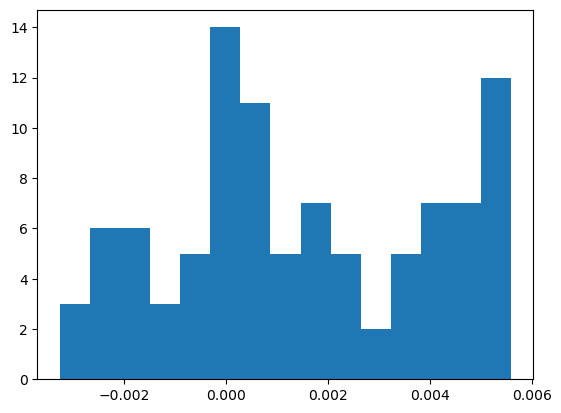

In [99]:
#histograma
plt.hist(lista, bins=15)
plt.show()

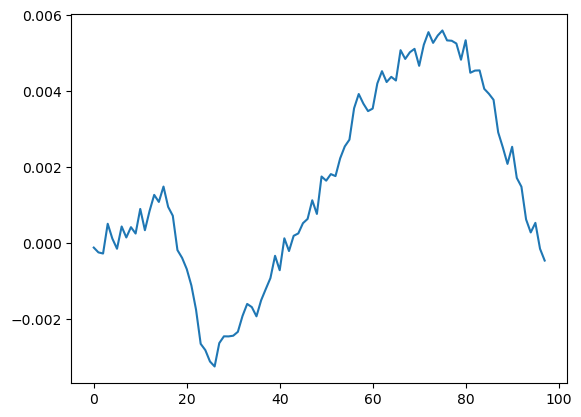

In [75]:
#Gráfico de lineas
plt.plot(lista)
plt.show()

y ahora la desviación muestral de cada ventana y ademas quiero la media y volatilidad de todo , y agregarle la linea de la media a la grafica de lineas

In [94]:
desviaciones = []

for i in range(96):

    valores = df['Rendimiento'].iloc[i:i+32]

    desviacion = np.std(valores, ddof=1)

    desviaciones.append(desviacion)

In [95]:
media_total = np.mean(df['Rendimiento'].dropna())
media_total

np.float64(0.0004902520608712074)

In [96]:
volatilidad_total = np.std(df['Rendimiento'].dropna(), ddof=1)
volatilidad_total

0.009958376759008743

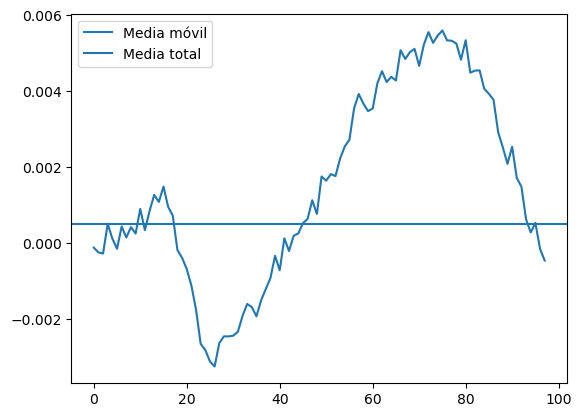

In [97]:
plt.plot(lista, label='Media móvil')

plt.axhline(media_total, label='Media total')

plt.legend()
plt.show()

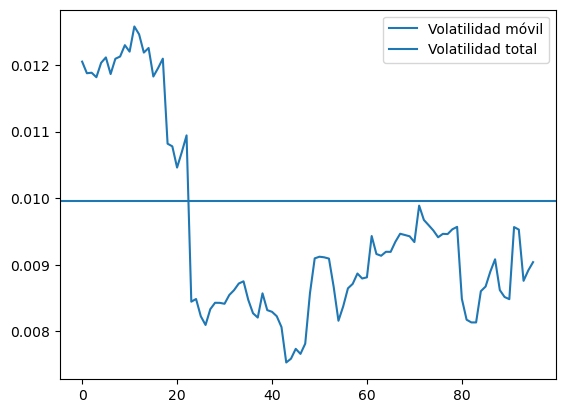

In [98]:
plt.plot(desviaciones, label='Volatilidad móvil')

plt.axhline(volatilidad_total, label='Volatilidad total')

plt.legend()
plt.show()